In [2]:
from ctypes import kind

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./assets/cleaned_5G_smartphone.csv')

In [21]:
df

,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,VoLTE,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
0,0,Samsung,Galaxy S25 Ultra,118998,4.15,True,True,True,True,True,...,3120,Android,False,NaN,200,12,4,1,Snapdragon,8 elite for galaxy
1,1,OnePlus,Nord 6,38999,4.60,True,True,True,True,True,...,2772,Android,False,NaN,50,32,2,1,Snapdragon,8s gen4
2,2,Samsung,Galaxy S25 FE,44999,4.70,True,True,True,True,True,...,2340,Android,False,NaN,50,12,3,1,Exynos,2400
3,3,Vivo,T5x 5G,18999,4.10,True,True,True,True,True,...,2344,Android,False,NaN,50,32,2,1,Dimensity,7400 turbo
4,4,Infinix,Note 60 Pro 5G,31999,4.75,True,True,True,True,True,...,2644,Android,True,1024.0,50,13,2,1,Snapdragon,7s gen4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,897,Tecno,Spark 10 5G,13800,4.55,True,True,True,True,True,...,1612,Android,True,1024.0,50,8,2,1,Dimensity,6020
898,898,Xiaomi,Redmi Note 12,18499,4.20,True,True,True,True,True,...,2400,Android,True,1024.0,48,13,3,1,Snapdragon,4 gen 1
899,899,Realme,11,18999,4.75,True,True,True,True,True,...,2400,Android,True,1024.0,108,16,2,1,Dimensity,6100 plus
900,900,Motorola,Razr 40 Ultra,59990,4.20,True,True,True,True,True,...,2640,iOS,False,NaN,13,32,2,1,Snapdragon,8+ gen1


In [7]:
df['os'].value_counts()

os
Android v15      356
Android v14      242
Android v16      146
Android v13       69
Android v12       23
iOS v18           14
iOS v26           12
iOS v17            6
Android v11        6
iOS v26.3          2
iOS v16            2
iOS v14.0          2
Android v10.0      2
iOS v15            1
Android 15 Go      1
Android v10        1
Name: count, dtype: int64

In [11]:
df['os'] = df['os'].apply(lambda x: "Android" if "Android" in str(x) else "iOS")

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 902 entries, 0 to 901
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pos                       902 non-null    int64  
 1   brand                     902 non-null    str    
 2   model                     902 non-null    str    
 3   price                     902 non-null    int64  
 4   rating                    902 non-null    float64
 5   Dual Sim                  902 non-null    bool   
 6   3G                        902 non-null    bool   
 7   4G                        902 non-null    bool   
 8   5G                        902 non-null    bool   
 9   VoLTE                     902 non-null    bool   
 10  Vo5G                      902 non-null    bool   
 11  Wi-Fi                     902 non-null    bool   
 12  NFC                       902 non-null    bool   
 13  IR Blaster                902 non-null    bool   
 14  processor_core       

In [20]:
df.isnull().sum()

pos                           0
brand                         0
model                         0
price                         0
rating                        0
Dual Sim                      0
3G                            0
4G                            0
5G                            0
VoLTE                         0
Vo5G                          0
Wi-Fi                         0
NFC                           0
IR Blaster                    0
processor_core                0
processor_speed_in_GHz       37
Ram                           0
storage                       0
battery_capacity              0
is_fast_charging              0
fast_charging_capacity       52
display_size                  0
display_refresh_rate         38
camera_notch_type             8
pixel_width                   0
pixel_height                  0
os                            0
is_memory_card_supported      0
max_card_gb                 610
primary_rear_mp               0
primary_front_mp              0
num_rear

## brand column univariate analysis
- Realme > Vivo = Samsung are the three dominating companies

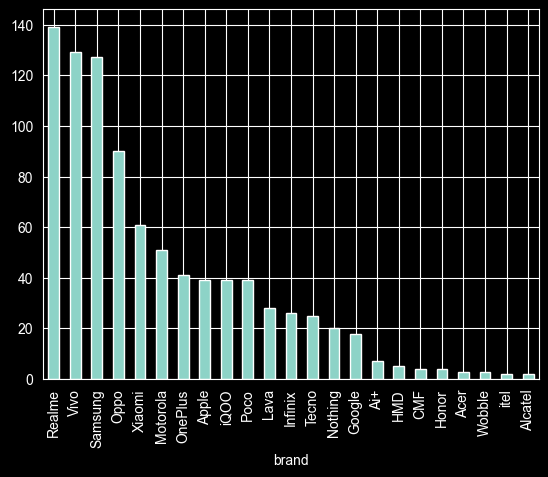

In [29]:
df['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/brand/bar_plot.png')


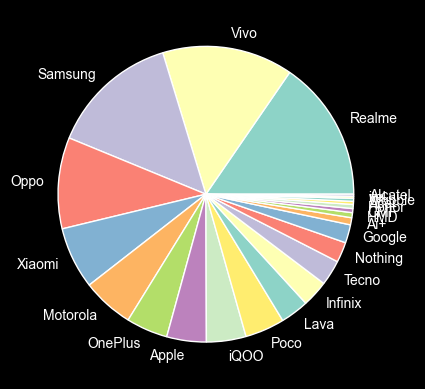

In [30]:
df['brand'].value_counts().plot(kind='pie')
plt.savefig('./plots/univariate_analysis/brand/pie_plot.png')

# price column univariate analysis
- budget phones are dominating

In [33]:
df['price'].describe()

count       902.000000
mean      36032.215078
std       31932.852245
min        7499.000000
25%       16999.000000
50%       24999.000000
75%       39968.250000
max      222990.000000
Name: price, dtype: float64

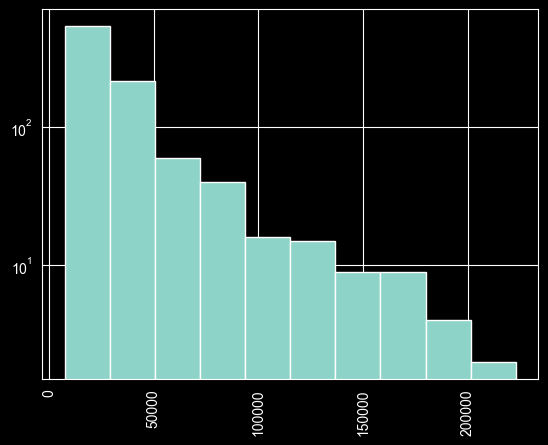

In [41]:
plt.hist(df['price'],bins=10,log=True)
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/price/hist_plot.png')

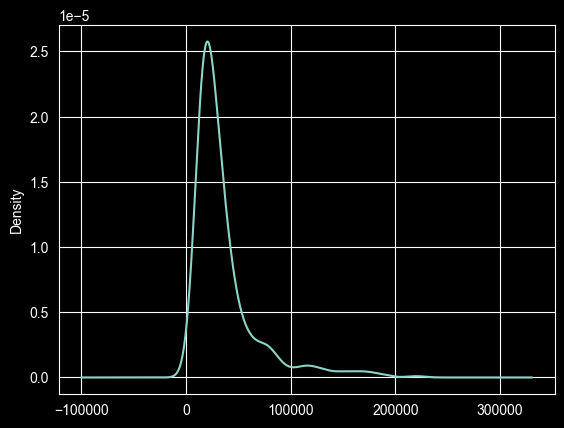

In [43]:
df['price'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/price/kde_plot.png')

# dual sim univariate analysis
- Except one phone all phones have dual sim

<Axes: xlabel='Dual Sim'>

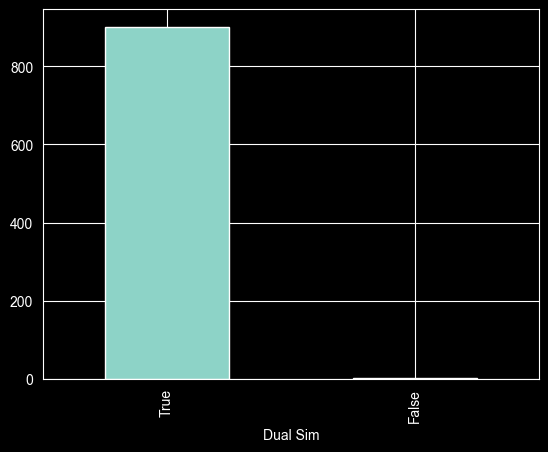

In [45]:
df['Dual Sim'].value_counts().plot(kind='bar')

# 3G univariate analysis
- all phones have 3G

# 4G univariate analysis
- all phones have 4G

# 5G univariate analysis
- all phones have 5G

# VoLTE univariate analysis
- Almost all phones have VoLTE except some Oppo, Realme and one Motorola phone

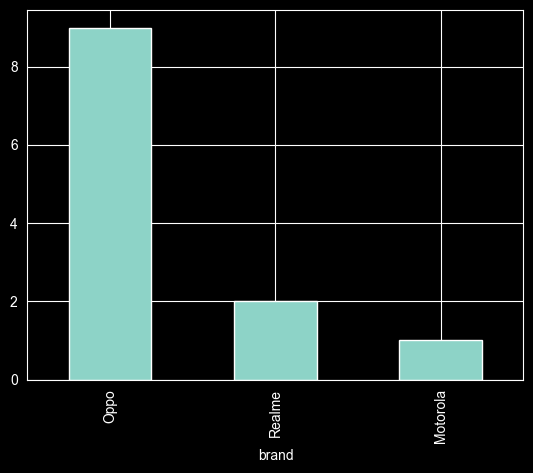

In [62]:
df[df['VoLTE'] == False]['brand'].value_counts().plot(kind='bar')
plt.savefig('./plots/univariate_analysis/VoLTE/bar_plot.png')

# Wi-Fi univariate analysis
- Every phone has Wi-Fi

# NFC univariate analysis
- Half of the phones have NFC

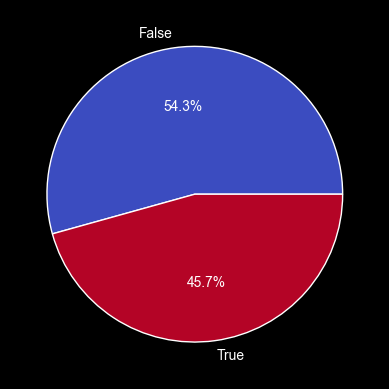

In [71]:
df['NFC'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/NFC/pie_plot.png')

# IR Blaster univariate analysis
-

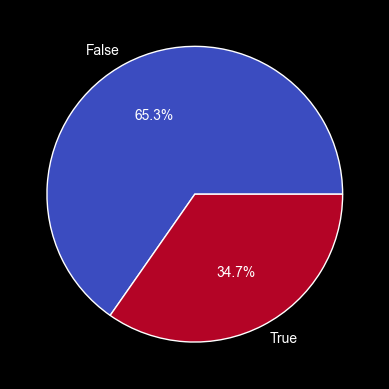

In [76]:
df['IR Blaster'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/IR_Blaster/pie_plot.png')

# processor_core univariate analysis
- 93.8% of the phones have 8 core processor

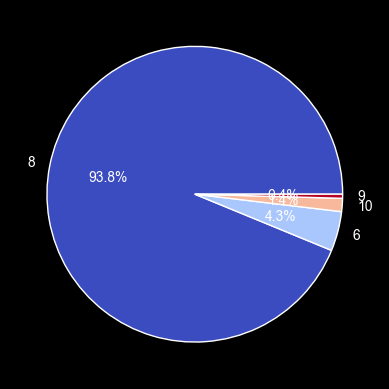

In [79]:
df['processor_core'].value_counts().plot(kind='pie',autopct='%1.1f%%',cmap='coolwarm')
plt.savefig('./plots/univariate_analysis/processor_core/pie_plot.png')

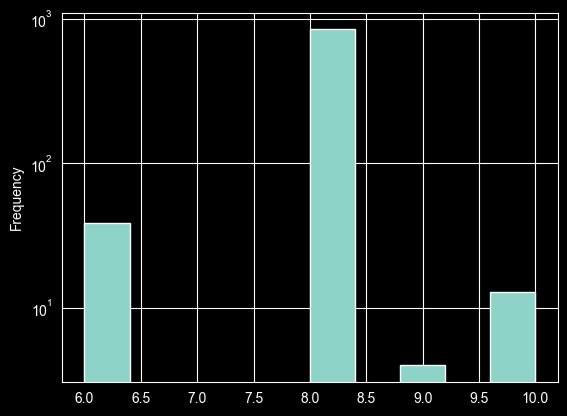

In [82]:
df['processor_core'].plot(kind='hist',log=True)
plt.savefig('./plots/univariate_analysis/processor_core/hist_plot.png')

# processor_speed_in_GHz univariate analysis
- majority of the processor has speed between 2.25 - 2.5 GHz
- weird anomaly between 3-3.5 GHz speed
- there are 53 outliers `(speed > 3.9 GHz)`

In [84]:
df['processor_speed_in_GHz'].describe()

count    865.000000
mean       2.750486
std        0.563318
min        2.000000
25%        2.400000
50%        2.500000
75%        3.000000
max        4.740000
Name: processor_speed_in_GHz, dtype: float64

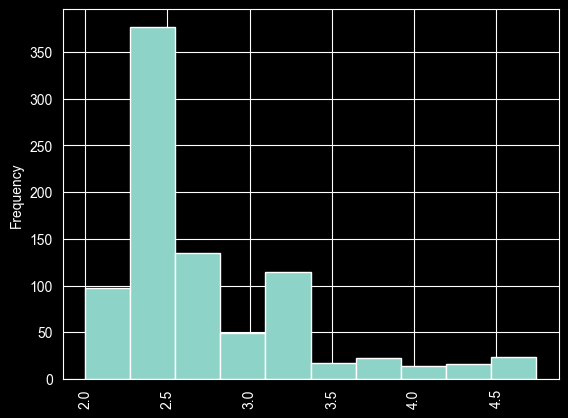

In [90]:
df['processor_speed_in_GHz'].plot(kind='hist')
plt.xticks(rotation=90)
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/hist_plot.png')

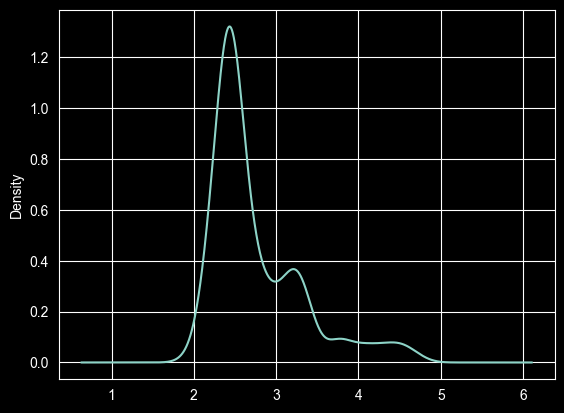

In [141]:
df['processor_speed_in_GHz'].plot(kind='kde')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/kde_plot.png')

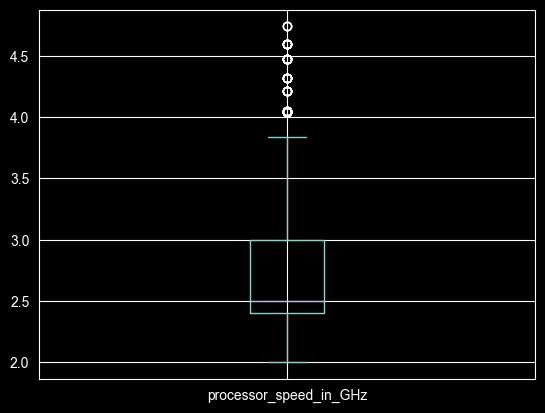

In [93]:
df['processor_speed_in_GHz'].plot(kind='box')
plt.savefig('./plots/univariate_analysis/processor_speed_in_GHz/box_plot.png')

### Fixing some missing and misplaced values in the os and battery_capacity columns

In [137]:
df[(df['processor_speed_in_GHz'] >= 3.0) & (df['processor_speed_in_GHz'] <= 3.5) ].groupby(['brand','os'])

KeyError: ('Vivo', 'iOS')

In [136]:
df.loc[[713],'os'] = "Android"

In [139]:
df.to_csv('../filled_osnNA_cleaned_5G_smartphone.csv')

In [140]:
df = pd.read_csv('./assets/filled_osnNA_cleaned_5G_smartphone.csv')

In [162]:
df[df['battery_capacity'].isna()]

,Unnamed: 0,pos,brand,model,price,rating,Dual Sim,3G,4G,5G,...,pixel_height,os,is_memory_card_supported,max_card_gb,primary_rear_mp,primary_front_mp,num_rear_cameras,num_front_cameras,processor_brand,processor_model
678,678,678,Apple,iPhone 12 Pro Max,119900,4.6,True,True,True,True,...,2778,iOS,False,NaN,12,12,3,1,Apple,A14
731,731,731,Apple,iPhone 12 Pro,109900,4.0,True,True,True,True,...,2532,iOS,False,NaN,12,12,3,1,Apple,A14


In [156]:
df.loc[[678,731],'battery_capacity']

678   NaN
731   NaN
Name: battery_capacity, dtype: float64

In [163]:
df.to_csv('./assets/final.csv',index=False)